# Reddit Engagement EDA

Цель: провести первичный анализ данных для предсказания `ups` и `num_comments` у Reddit-постов.

In [ ]:
!python eda/load_reddit.py \
  --subreddits technology \
  --start-date 2026-03-01 \
  --end-date 2026-04-10 \
  --max-posts-per-day 300000 \
  --output-file eda/reddit.csv

In [90]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)

DATASET_FILENAME = Path('reddit.csv')
TARGETS = ['ups', 'num_comments']

In [91]:
df = pd.read_csv(DATASET_FILENAME)

for column in ['ups', 'num_comments', 'score', 'upvote_ratio', 'subreddit_subscribers', 'created_utc', 'retrieved_on', 'thumbnail_height', 'thumbnail_width']:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors='coerce')

df['created_dt'] = pd.to_datetime(df['created_utc'], unit='s', utc=True, errors='coerce')
df['retrieved_dt'] = pd.to_datetime(df['retrieved_on'], unit='s', utc=True, errors='coerce')
df['age_seconds'] = (df['retrieved_dt'] - df['created_dt']).dt.total_seconds()
df['hour'] = df['created_dt'].dt.hour
df['day_of_week'] = df['created_dt'].dt.day_name()
df['date'] = df['created_dt'].dt.date

title_series = df['title'].astype('string')
selftext_series = df['selftext'].astype('string')
thumbnail_series = df['thumbnail'].astype('string')
removed_series = df['removed_by_category'].astype('string')

df['title_len'] = title_series.str.len()
df['selftext_len'] = selftext_series.str.len()
df['title_word_count'] = title_series.str.findall(r'\w+').str.len()
df['has_selftext'] = selftext_series.notna() & selftext_series.ne('')
df['has_thumbnail'] = thumbnail_series.notna() & ~thumbnail_series.isin(['self', 'default', 'nsfw', 'image', 'spoiler', 'missing', ''])
df['is_removed'] = removed_series.notna() & removed_series.ne('')
df['title_has_question'] = title_series.str.contains(r'\?', regex=True, na=False)
df['title_has_number'] = title_series.str.contains(r'\d', regex=True, na=False)
df['title_upper_share'] = title_series.str.count(r'[A-Z]').div(df['title_len'].replace(0, np.nan))

df.head()

,id,subreddit,title,score,ups,upvote_ratio,num_comments,created_utc,retrieved_on,age_seconds,...,date,title_len,selftext_len,title_word_count,has_selftext,has_thumbnail,is_removed,title_has_question,title_has_number,title_upper_share
0,1rhig6r,technology,How to Password Protect a Folder on Mac | How ...,1,1,1.0,1,1772323970,1772323994,24.0,...,2026-03-01,85,<NA>,18,False,True,True,False,False,0.117647
1,1rhii4c,technology,X Is Drowning in Disinformation Following US a...,1,1,1.0,0,1772324110,1772324133,23.0,...,2026-03-01,72,<NA>,13,False,True,True,False,False,0.138889
2,1rhiiwf,technology,Spotify – Web Player,1,1,1.0,0,1772324168,1772324191,23.0,...,2026-03-01,20,<NA>,3,False,True,True,False,False,0.15
3,1rhio4k,technology,390TB video game archive being taken offline d...,1,1,1.0,0,1772324557,1772324580,23.0,...,2026-03-01,191,<NA>,32,False,True,True,False,True,0.052356
4,1rhj4s6,technology,A Day in the Life of an Ensh*ttificator --- Fo...,1,1,1.0,1,1772325769,1772325794,25.0,...,2026-03-01,87,<NA>,13,False,True,True,False,False,0.091954


## 1. Общая информация

In [92]:
overview = pd.DataFrame({
    'metric': [
        'rows',
        'columns',
        'unique_ids',
        'duplicate_ids',
        'date_min_utc',
        'date_max_utc',
        'removed_share',
        'selftext_nonempty_share',
        'thumbnail_share',
        'score_equals_ups_share',
        'median_age_seconds'
    ],
    'value': [
        len(df),
        df.shape[1],
        df['id'].nunique(),
        len(df) - df['id'].nunique(),
        df['created_dt'].min(),
        df['created_dt'].max(),
        round(df['is_removed'].mean(), 4),
        round(df['has_selftext'].mean(), 4),
        round(df['has_thumbnail'].mean(), 4),
        round((df['score'] == df['ups']).mean(), 4),
        df['age_seconds'].median()
    ]
})

drop_candidates = pd.DataFrame({
    'column': ['id', 'url', 'score', 'retrieved_on'],
    'reason': [
        'identifier only',
        'high-cardinality raw string',
        'duplicates ups in current dataset',
        'not available at publication time'
    ]
})

display(overview)
display(drop_candidates)

,metric,value
0,rows,5053
1,columns,41
2,unique_ids,5053
3,duplicate_ids,0
4,date_min_utc,2026-03-01 00:12:50+00:00
5,date_max_utc,2026-04-09 23:58:39+00:00
6,removed_share,0.4273
7,selftext_nonempty_share,0.0657
8,thumbnail_share,0.7867
9,score_equals_ups_share,1.0


,column,reason
0,id,identifier only
1,url,high-cardinality raw string
2,score,duplicates ups in current dataset
3,retrieved_on,not available at publication time


## 2. Пропуски

In [93]:
missing_profile = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_share': df.isna().mean().round(4),
    'n_unique': df.nunique(dropna=True)
}).sort_values(['missing_share', 'n_unique'], ascending=[False, False])

display(missing_profile.head(20))

,dtype,missing,missing_share,n_unique
selftext,str,4721,0.9343,2
selftext_len,Int64,4721,0.9343,1
removed_by_category,str,2894,0.5727,5
post_hint,str,1063,0.2104,4
thumbnail_height,float64,784,0.1552,91
thumbnail_width,float64,784,0.1552,6
domain,str,323,0.0639,1375
url,str,322,0.0637,4537
thumbnail,str,28,0.0055,3705
id,str,0,0.0000,5053


## 3. Таргеты

In [94]:
target_summary = df[TARGETS].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T
target_summary['zero_share'] = [(df[target] == 0).mean().round(4) for target in TARGETS]

display(target_summary)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max,zero_share
ups,5053.0,887.877696,3524.367831,0.0,1.0,1.0,132.0,1628.6,4289.0,21658.56,52839.0,0.1286
num_comments,5053.0,72.054027,274.383919,0.0,0.0,1.0,26.0,157.0,346.4,1261.96,6902.0,0.2949


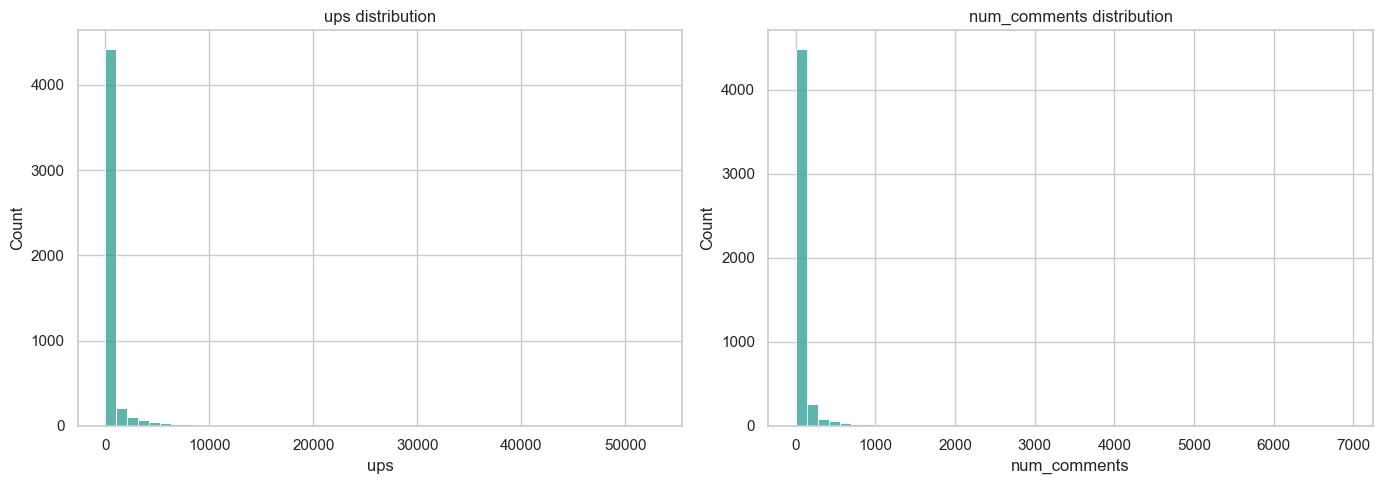

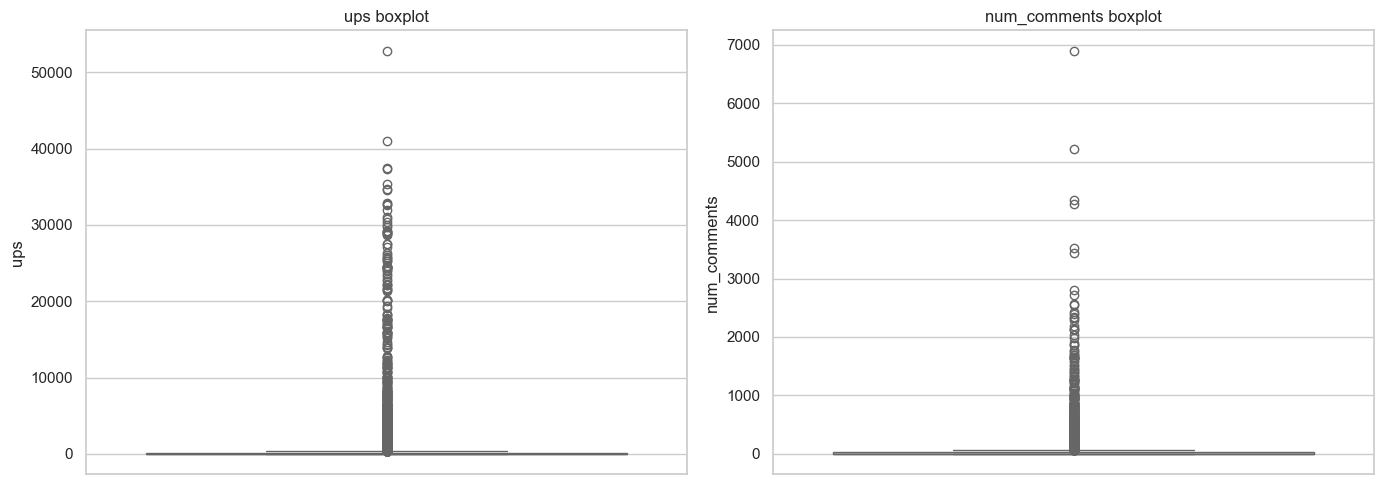

In [95]:
fig, axes = plt.subplots(1, len(TARGETS), figsize=(14, 5))

for idx, target in enumerate(TARGETS):
    sns.histplot(df[target].dropna(), bins=50, ax=axes[idx], color='#2a9d8f')
    axes[idx].set_title(f'{target} distribution')
    axes[idx].set_xlabel(target)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(TARGETS), figsize=(14, 5))

for idx, target in enumerate(TARGETS):
    sns.boxplot(y=df[target], ax=axes[idx], color='#e9c46a')
    axes[idx].set_title(f'{target} boxplot')
    axes[idx].set_ylabel(target)

plt.tight_layout()
plt.show()

## 4. Корреляции и числовые признаки

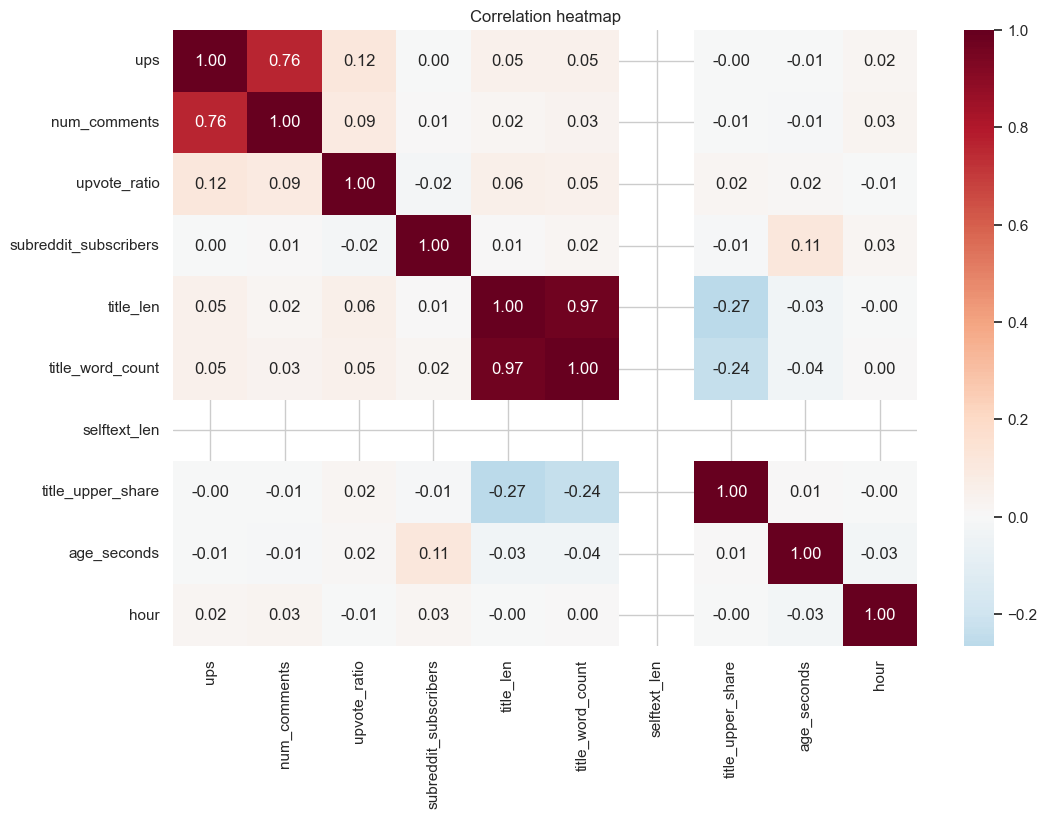

In [96]:
numeric_columns = [
    'ups',
    'num_comments',
    'upvote_ratio',
    'subreddit_subscribers',
    'title_len',
    'title_word_count',
    'selftext_len',
    'title_upper_share',
    'age_seconds',
    'hour'
]
numeric_columns = [column for column in numeric_columns if column in df.columns]

corr = df[numeric_columns].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation heatmap')
plt.show()

## 5. Время публикации

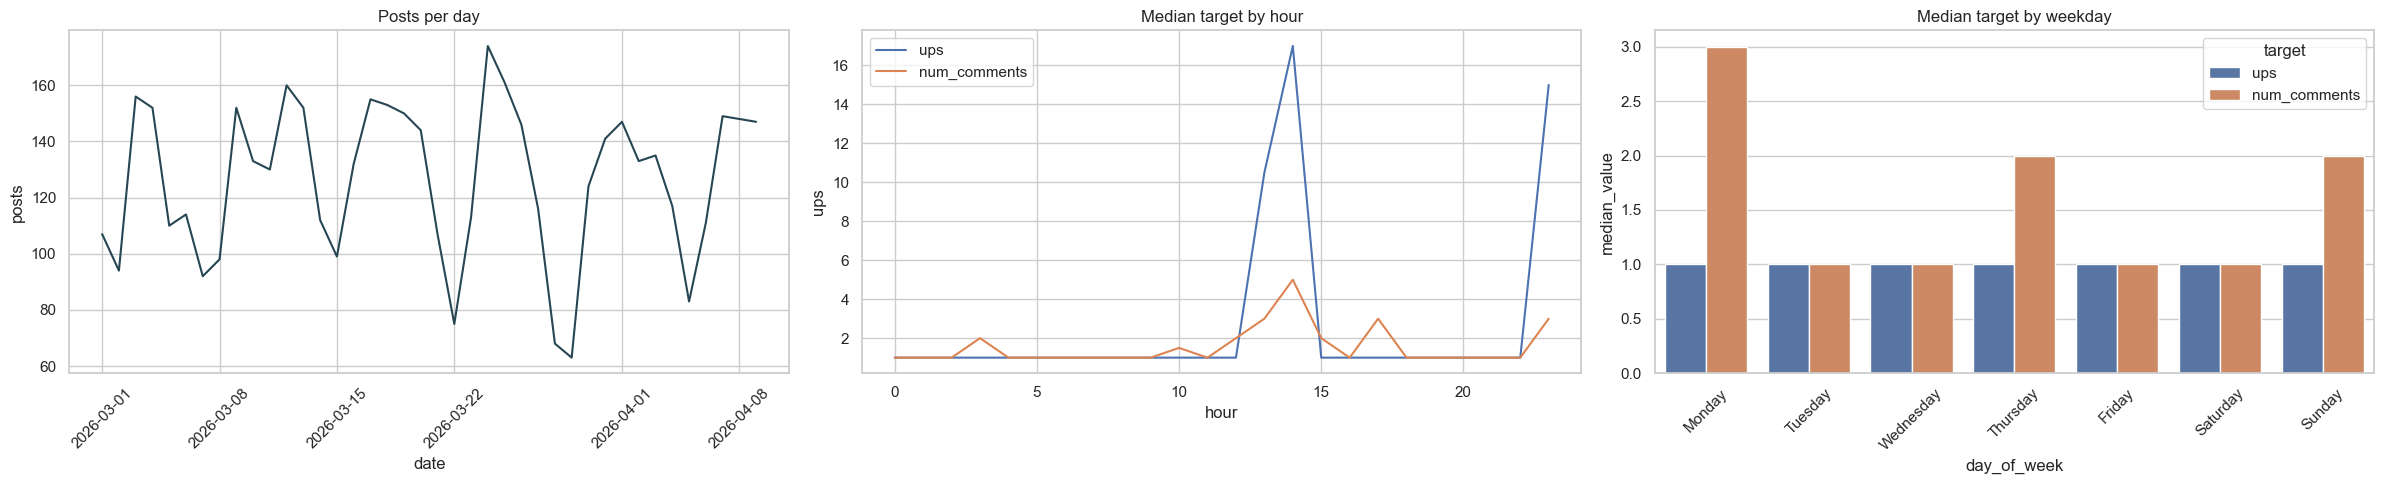

In [97]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_volume = df.groupby('date').size().rename('posts').reset_index()
hourly_stats = df.groupby('hour')[TARGETS].median().reset_index()
weekday_stats = df.groupby('day_of_week')[TARGETS].median().reindex(weekday_order).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(24, 5))
sns.lineplot(data=daily_volume, x='date', y='posts', ax=axes[0], color='#264653')
axes[0].set_title('Posts per day')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=hourly_stats, x='hour', y='ups', ax=axes[1], label='ups')
sns.lineplot(data=hourly_stats, x='hour', y='num_comments', ax=axes[1], label='num_comments')
axes[1].set_title('Median target by hour')

sns.barplot(
    data=weekday_stats.melt(id_vars='day_of_week', var_name='target', value_name='median_value'),
    x='day_of_week',
    y='median_value',
    hue='target',
    ax=axes[2]
)
axes[2].set_title('Median target by weekday')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

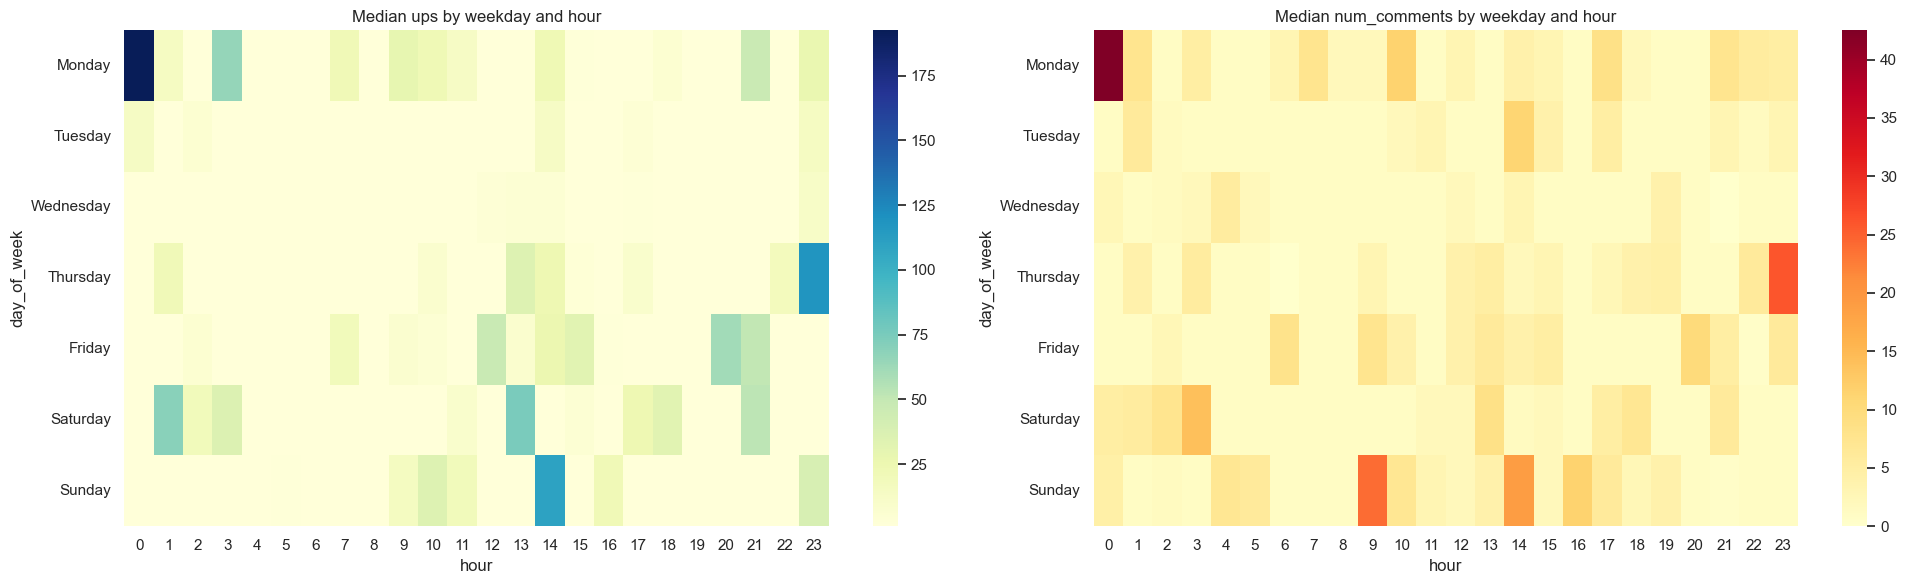

In [98]:
hour_weekday_ups = df.pivot_table(index='day_of_week', columns='hour', values='ups', aggfunc='median').reindex(weekday_order)
hour_weekday_comments = df.pivot_table(index='day_of_week', columns='hour', values='num_comments', aggfunc='median').reindex(weekday_order)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
sns.heatmap(hour_weekday_ups, cmap='YlGnBu', ax=axes[0])
axes[0].set_title('Median ups by weekday and hour')
sns.heatmap(hour_weekday_comments, cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Median num_comments by weekday and hour')

plt.tight_layout()
plt.show()

## 6. Категориальные признаки

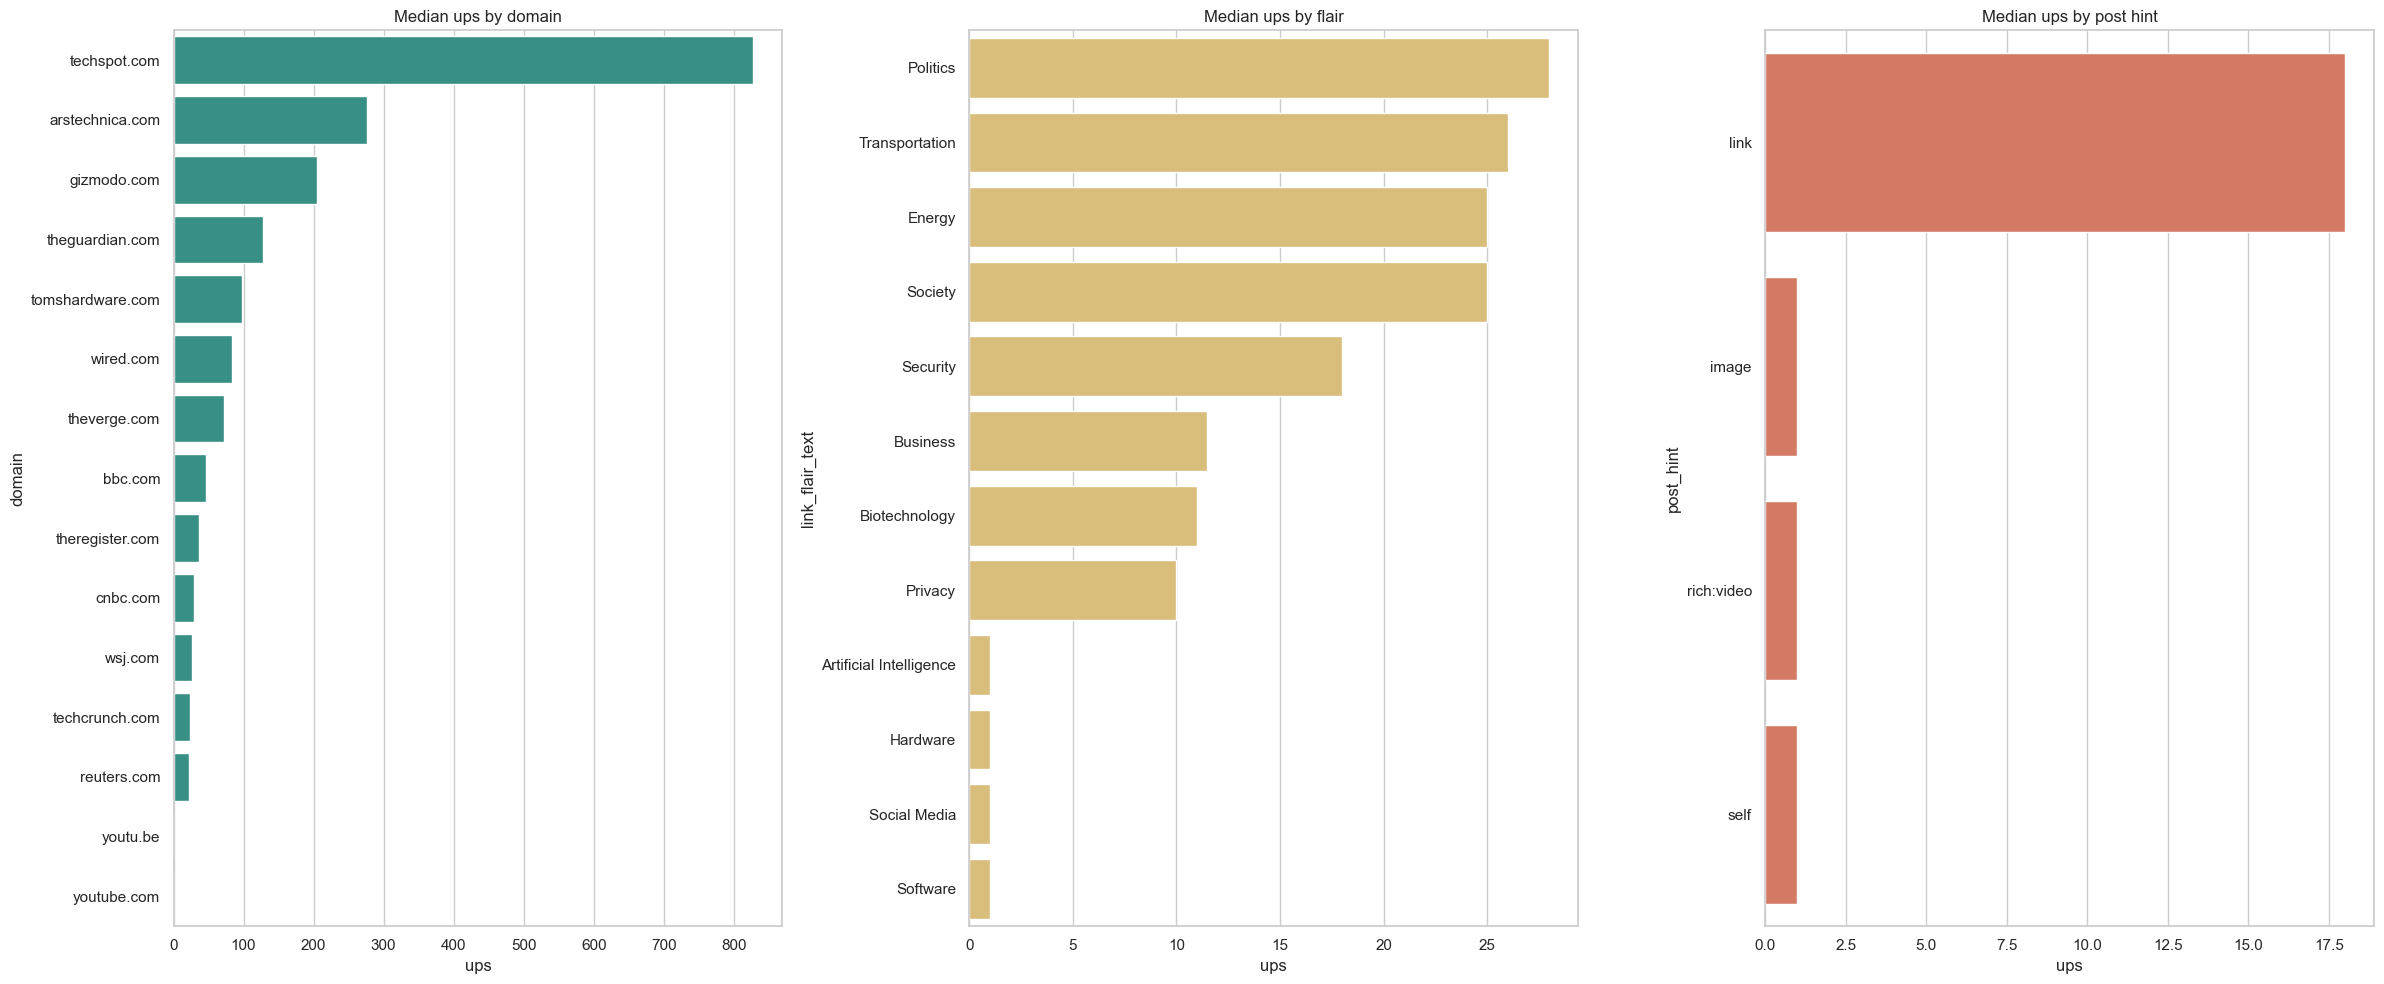

In [99]:
top_domains = df['domain'].dropna().value_counts().head(15).index
top_flairs = df['link_flair_text'].dropna().value_counts().head(12).index
top_post_hints = df['post_hint'].dropna().value_counts().head(8).index

domain_stats = df[df['domain'].isin(top_domains)].groupby('domain')[TARGETS].median().sort_values('ups', ascending=False).reset_index()
flair_stats = df[df['link_flair_text'].isin(top_flairs)].groupby('link_flair_text')[TARGETS].median().sort_values('ups', ascending=False).reset_index()
hint_stats = df[df['post_hint'].isin(top_post_hints)].groupby('post_hint')[TARGETS].median().sort_values('ups', ascending=False).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(24, 10))
sns.barplot(data=domain_stats, y='domain', x='ups', ax=axes[0], color='#2a9d8f')
axes[0].set_title('Median ups by domain')
sns.barplot(data=flair_stats, y='link_flair_text', x='ups', ax=axes[1], color='#e9c46a')
axes[1].set_title('Median ups by flair')
sns.barplot(data=hint_stats, y='post_hint', x='ups', ax=axes[2], color='#e76f51')
axes[2].set_title('Median ups by post hint')

plt.tight_layout()
plt.show()

## 7. Текстовая предобработка

In [100]:
text_df = df.loc[df['title'].notna(), ['title', 'ups', 'num_comments']].copy()
text_df['title'] = text_df['title'].astype('string').str.lower()
text_df['tokens'] = text_df['title'].str.findall(r'[a-z0-9]+')
text_df['tokens_wo_stopwords'] = text_df['tokens'].apply(lambda tokens: [token for token in tokens if token not in ENGLISH_STOP_WORDS])
text_df['token_count'] = text_df['tokens'].str.len()
text_df['token_count_wo_stopwords'] = text_df['tokens_wo_stopwords'].str.len()

top_tokens = text_df['tokens'].explode().dropna().value_counts().head(25).rename_axis('token').reset_index(name='count')
top_tokens_wo_stopwords = text_df['tokens_wo_stopwords'].explode().dropna().value_counts().head(25).rename_axis('token').reset_index(name='count')

display(top_tokens)
display(top_tokens_wo_stopwords)

,token,count
0,the,1821
1,to,1808
2,ai,1404
3,s,1213
4,a,1138
5,in,1103
6,and,1061
7,of,1051
8,for,810
9,is,769


,token,count
0,ai,1404
1,s,1213
2,new,335
3,data,249
4,says,249
5,t,213
6,meta,210
7,tech,197
8,anthropic,179
9,openai,169


In [101]:
popular_threshold = text_df['ups'].quantile(0.9)
text_df['is_popular'] = text_df['ups'] >= popular_threshold

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=5, max_df=0.95, stop_words='english')
title_tfidf = tfidf.fit_transform(text_df['title'])
vocab = np.array(tfidf.get_feature_names_out())

popular_mean = title_tfidf[text_df['is_popular'].values].mean(axis=0).A1
non_popular_mean = title_tfidf[~text_df['is_popular'].values].mean(axis=0).A1
keyword_table = pd.DataFrame({
    'ngram': vocab,
    'popular_mean': popular_mean,
    'non_popular_mean': non_popular_mean,
    'lift': popular_mean - non_popular_mean
}).sort_values('lift', ascending=False)

display(keyword_table.head(25))

,ngram,popular_mean,non_popular_mean,lift
614,data,0.020532,0.010011,0.010520
1893,says,0.019818,0.009782,0.010036
426,centers,0.011351,0.002310,0.009041
617,data centers,0.011351,0.002310,0.009041
1177,iran,0.014950,0.006583,0.008367
631,deal,0.010981,0.003012,0.007970
705,dlss,0.007595,0.000475,0.007120
1361,makes,0.008213,0.001180,0.007032
0,000,0.012202,0.005260,0.006942
1539,openai,0.014852,0.008401,0.006452


## 8. Срез для моделирования

In [102]:
model_df = df.drop(columns=['id', 'url', 'score', 'retrieved_on'], errors='ignore').copy()
model_df = model_df.loc[~model_df['is_removed']].copy()
model_df = model_df.loc[model_df['title'].notna()].copy()

model_overview = pd.DataFrame({
    'metric': ['rows_raw', 'rows_model', 'share_kept'],
    'value': [len(df), len(model_df), round(len(model_df) / len(df), 4)]
})

display(model_overview)
display(model_df.head())

,metric,value
0,rows_raw,5053.0000
1,rows_model,2894.0000
2,share_kept,0.5727


,subreddit,title,ups,upvote_ratio,num_comments,created_utc,age_seconds,selftext,author,is_self,...,date,title_len,selftext_len,title_word_count,has_selftext,has_thumbnail,is_removed,title_has_question,title_has_number,title_upper_share
13,technology,Lawmakers Demand DHS Define ‘Domestic Terroris...,2721,0.98,41,1772332600,21.0,NaN,ControlCAD,False,...,2026-03-01,300,<NA>,46,False,True,False,False,False,0.086667
15,technology,Sam Altman Answers Questions on X.com About Pe...,1015,0.90,150,1772332840,24.0,NaN,gadgetygirl,False,...,2026-03-01,79,<NA>,13,False,True,False,False,False,0.126582
21,technology,Creepy ‘Marathon’ AI Enemies Are Mimicking Pla...,340,0.73,98,1772337242,27.0,NaN,TylerFortier_Photo,False,...,2026-03-01,59,<NA>,9,False,True,False,False,False,0.169492
23,technology,Claude hits No. 1 on App Store as ChatGPT user...,37373,0.94,1145,1772341483,20.0,NaN,Ephoenix6,False,...,2026-03-01,105,<NA>,20,False,True,False,False,True,0.095238
24,technology,Open-source AI tool beats giant LLMs in litera...,87,0.86,4,1772343616,18.0,NaN,ubcstaffer123,False,...,2026-03-01,85,<NA>,14,False,False,False,False,False,0.070588
